# Thai Vowel Classification — CNN+LSTM + Mel Spectrogram (CMVN)

**Model:** CNN → Reshape → Bidirectional LSTM + Bahdanau Attention → Dense

**Input:** Log-Mel Spectrogram

**Evaluation:** 10% held-out test set → Stratified 5-Fold CV on remaining 90%

**Preprocessing:** smart_crop() (peak-energy 500 ms window)

**Upgrades:** Data Augmentation · Label Smoothing · ReduceLROnPlateau

## Section 1 — Setup

In [1]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import matplotlib.font_manager as fm
import urllib.request
from pydub import AudioSegment
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Mounted at /content/drive


In [2]:
# ── Constants ───────────────────────────────────────────────
SR          = 16000
HOP_LENGTH  = 512
N_FFT       = 2048
N_CLASSES   = 18
EPOCHS      = 500
BATCH_SIZE  = 32
RANDOM_SEED = 42
N_FOLDS     = 5

VOWEL_LABELS = [
    'อา','อี','อือ','อู','เอ','แอ','โอ','ออ','เออ',
    'อะ','อิ','อึ','อุ','เอะ','แอะ','โอะ','เอาะ','เออะ'
]

# ── Fix Random Seed ─────────────────────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'Random seed fixed: {RANDOM_SEED}')

Random seed fixed: 42


## Section 2 — Load Dataset

In [3]:
base_path = r'/content/drive/My Drive/dataset'

data = []
for label in os.listdir(base_path):
    folder = os.path.join(base_path, label)
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            if file.endswith('.wav'):
                data.append([os.path.join(folder, file), label])

df = pd.DataFrame(data, columns=['file_path', 'label'])
print(f'Total samples : {len(df)}')
print(df['label'].value_counts())

Total samples : 1800
label
s7    100
s4    100
s8    100
s3    100
s2    100
s9    100
s1    100
s6    100
09    100
s5    100
08    100
07    100
05    100
06    100
04    100
03    100
02    100
01    100
Name: count, dtype: int64


## Section 3 — Preprocessing Functions

In [4]:
def detect_leading_silence(sound, silence_threshold=-30.0, chunk_size=10):
    """Trim silence from both ends."""
    trim_ms = 0
    while trim_ms < len(sound) and sound[trim_ms:trim_ms+chunk_size].dBFS < silence_threshold:
        trim_ms += chunk_size
    return trim_ms


def smart_crop(file_path, output_dir, window_ms=500, silence_threshold=-30.0):
    """
    Peak-energy crop: trim silence → find frame with max RMS energy
    → crop window_ms centred on that peak.
    Replaces the old fixed 25-50-25 crop.
    """
    os.makedirs(output_dir, exist_ok=True)
    sound = AudioSegment.from_file(file_path)

    start = detect_leading_silence(sound, silence_threshold)
    end   = detect_leading_silence(sound.reverse(), silence_threshold)
    trimmed = sound[start : len(sound) - end]

    if len(trimmed) == 0:
        trimmed = sound

    chunk_ms  = 10
    energies  = [trimmed[i:i+chunk_ms].rms for i in range(0, len(trimmed), chunk_ms)]
    peak_idx  = int(np.argmax(energies))
    peak_ms   = peak_idx * chunk_ms

    half       = window_ms // 2
    crop_start = max(0, peak_ms - half)
    crop_end   = min(len(trimmed), crop_start + window_ms)
    final      = trimmed[crop_start:crop_end]

    out_path = os.path.join(output_dir, f'sc_{os.path.basename(file_path)}')
    final.export(out_path, format='wav')
    return out_path

## Section 4 — Feature Extraction (Log-Mel Spectrogram + CMVN)

In [5]:
def extract_mel(file_path, max_len=18):
    wave, _ = librosa.load(file_path, mono=True, sr=SR)
    mel    = librosa.feature.melspectrogram(y=wave, sr=SR,
                                             n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0,0),(0, max_len - mel_db.shape[1])), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]

    # Step 1: Global norm (เหมือนเดิม — เก็บ energy contour ไว้)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    # Step 2: CMVN เบาๆ ด้วย alpha=0.5 (ลด speaker bias แต่ไม่ลบ energy ทิ้ง)
    alpha  = 0.5
    mean   = mel_db.mean(axis=1, keepdims=True)
    std    = mel_db.std(axis=1,  keepdims=True) + 1e-6
    mel_db = mel_db - alpha * mean   # shift mean เท่านั้น ไม่หาร std

    return mel_db

## Section 4.5 — Data Augmentation

สร้างเสียงเสมือนจาก 90 → ~360 ไฟล์ต่อ class  
ใช้ pitch shift / time stretch / gaussian noise

In [6]:
def augment_mel(mel_db):
    """
    Apply random augmentation directly on Mel spectrogram (faster than audio).
    Returns list of augmented spectrograms (NOT including original).
    """
    augmented = []

    # ── Time shift: roll along time axis ──────────────────────────────────
    shift = np.random.randint(1, max(2, mel_db.shape[1] // 4))
    augmented.append(np.roll(mel_db, shift, axis=1))

    # ── Frequency masking (SpecAugment-lite) ──────────────────────────────
    mel_fm = mel_db.copy()
    f0 = np.random.randint(0, mel_db.shape[0] // 4)
    f_width = np.random.randint(4, 12)
    mel_fm[f0:f0+f_width, :] = mel_db.mean()
    augmented.append(mel_fm)

    # ── Time masking (SpecAugment-lite) ───────────────────────────────────
    mel_tm = mel_db.copy()
    t0 = np.random.randint(0, max(1, mel_db.shape[1] - 4))
    t_width = np.random.randint(1, max(2, mel_db.shape[1] // 6))
    mel_tm[:, t0:t0+t_width] = mel_db.mean()
    augmented.append(mel_tm)

    # ── Gaussian noise ─────────────────────────────────────────────────────
    noise = np.random.normal(0, 0.05, mel_db.shape)
    augmented.append(mel_db + noise)

    return augmented  # 4 variants per sample


def build_augmented_dataset(X, y, seed=42):
    """
    Expand dataset with augmentation: 1 original → 5 total (1 + 4 augmented).
    """
    np.random.seed(seed)
    X_aug, y_aug = [X], [y]
    for variant in range(4):
        X_new = np.array([augment_mel(x)[variant] for x in X])
        X_aug.append(X_new)
        y_aug.append(y)
    X_aug = np.concatenate(X_aug, axis=0)
    y_aug = np.concatenate(y_aug, axis=0)

    # Shuffle
    idx = np.random.permutation(len(X_aug))
    return X_aug[idx], y_aug[idx]


print('Augmentation functions ready.')
print('Each sample → 5x (1 original + 4 augmented variants)')

Augmentation functions ready.
Each sample → 5x (1 original + 4 augmented variants)


## Section 5 — Dataset Analysis (duration percentiles)

Run once to justify MAX_LEN choice.

In [7]:
durations = []
for fp in tqdm(df['file_path'], desc='Measuring durations'):
    y, _ = librosa.load(fp, sr=SR)
    durations.append(len(y) / SR)

durations = np.array(durations)
print('Duration stats (seconds):')
for p in [25, 50, 75, 90, 95]:
    frames = int(np.percentile(durations, p) * SR / HOP_LENGTH)
    print(f'  p{p}: {np.percentile(durations, p):.3f}s → {frames} frames')

Measuring durations: 100%|██████████| 1800/1800 [23:13<00:00,  1.29it/s]

Duration stats (seconds):
  p25: 0.123s → 3 frames
  p50: 0.226s → 7 frames
  p75: 0.375s → 11 frames
  p90: 0.491s → 15 frames
  p95: 0.576s → 18 frames


## Section 6 — Build Full Dataset

In [8]:
PROC_DIR  = '/content/proc_smartcrop'
MAX_LEN   = 18  # p95 from duration analysis

processed_paths = [
    smart_crop(fp, PROC_DIR)
    for fp in tqdm(df['file_path'], desc='smart_crop')
]

X = np.array([
    extract_mel(p, max_len=MAX_LEN)
    for p in tqdm(processed_paths, desc='Mel extraction')
])  # (N, N_MELS, MAX_LEN)

le    = LabelEncoder()
y_int = le.fit_transform(df['label'])

print(f'X shape : {X.shape}')
print(f'Classes : {le.classes_}')

Mel extraction:   0%|          | 0/1800 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1712
  warnings.warn(
Mel extraction:   0%|          | 1/1800 [00:01<29:59,  1.00s/it]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1872
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1504
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2000
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1136
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too

X shape : (1800, 128, 18)
Classes : ['01' '02' '03' '04' '05' '06' '07' '08' '09' 's1' 's2' 's3' 's4' 's5'
 's6' 's7' 's8' 's9']


## Section 7 — Hold-Out Test Split (10%)

In [9]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_int,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=y_int
)

print(f'Train+Val : {X_trainval.shape[0]} samples')
print(f'Test      : {X_test.shape[0]} samples  ← ไม่แตะจนกว่าจะ train final model เสร็จ')

Train+Val : 1620 samples
Test      : 180 samples  ← ไม่แตะจนกว่าจะ train final model เสร็จ


## Section 8 — Model Architecture (CNN)

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# ── Attention Layer ──
class BahdanauAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, lstm_output):
        score   = self.V(tf.nn.tanh(self.W(lstm_output)))  # (batch, time, 1)
        weights = tf.nn.softmax(score, axis=1)              # (batch, time, 1)
        context = tf.reduce_sum(weights * lstm_output, axis=1)  # (batch, units)
        return context, weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.W.units})
        return config

def build_model(input_shape):

    inp = layers.Input(shape=input_shape)

    # ── CNN block ──
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Permute((2, 1, 3))(x)
    shape = x.shape
    x = layers.Reshape((shape[1], shape[2] * shape[3]))(x)

    # ── LSTM block ──
    x = layers.LSTM(512, activation='tanh', return_sequences=True, dropout=0.35)(x)
    x = layers.LSTM(512, activation='tanh', return_sequences=True, dropout=0.35)(x)
    x = layers.Dropout(0.35)(x)


    context, attn_weights = BahdanauAttention(512)(x)


    out = layers.Dense(N_CLASSES, activation='softmax')(context)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

dummy = build_model((X_trainval.shape[1], X_trainval.shape[2], 1))
dummy.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 18, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 18, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 18, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 18, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 18, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 18, 512)        │     5,244,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 18, 512)        │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention              │ [(None, 512), (None,   │       263,169 │
│ (BahdanauAttention)             │ 18, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │         9,234 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,635,731 (29.13 MB)

 Trainable params: 7,635,539 (29.13 MB)

 Non-trainable params: 192 (768.00 B)

## Section 9 — Stratified 5-Fold Cross-Validation

In [11]:
skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fold_results = []

X_tv = X_trainval[..., np.newaxis]  # add channel dim

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    print(f'\n── Fold {fold}/{N_FOLDS} ──')

    random.seed(RANDOM_SEED * fold)
    np.random.seed(RANDOM_SEED * fold)
    tf.random.set_seed(RANDOM_SEED * fold)

    X_tr,  X_val  = X_tv[tr_idx],      X_tv[val_idx]
    y_tr,  y_val  = y_trainval[tr_idx], y_trainval[val_idx]

    # ── Data Augmentation บน training fold เท่านั้น ──────────────────────
    X_tr_sq  = X_tr.squeeze(-1)           # (N, n_mels, max_len)
    X_tr_aug, y_tr_aug = build_augmented_dataset(X_tr_sq, y_tr, seed=RANDOM_SEED * fold)
    X_tr_aug = X_tr_aug[..., np.newaxis]  # เพิ่ม channel dim กลับ

    y_tr_cat  = to_categorical(y_tr_aug, N_CLASSES)
    y_val_cat = to_categorical(y_val,    N_CLASSES)

    model = build_model(X_tr_aug.shape[1:])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=8, min_lr=1e-6, verbose=0),
    ]

    model.fit(
        X_tr_aug, y_tr_cat,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val_cat),
        callbacks=callbacks, verbose=0
    )

    val_loss,   val_acc_eval   = model.evaluate(X_val,    y_val_cat, verbose=0)
    train_loss, train_acc_eval = model.evaluate(X_tr_aug, y_tr_cat,  verbose=0)

    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    f1     = f1_score(y_val, y_pred, average='macro')
    acc    = np.mean(y_pred == y_val)

    fold_results.append({
        'fold': fold,
        'val_acc': acc,
        'val_f1_macro': f1,
        'val_loss': val_loss,
        'train_loss': train_loss,
    })
    print(f'  Val Acc: {acc*100:.2f}%   Macro F1: {f1:.4f}   Val Loss: {val_loss:.4f}   Train Loss: {train_loss:.4f}')

df_folds = pd.DataFrame(fold_results)
print('\n' + '='*55)
print('  CV Summary')
print('='*55)
print(f"  Val Acc    : {df_folds['val_acc'].mean()*100:.2f}% ± {df_folds['val_acc'].std()*100:.2f}%")
print(f"  Macro F1   : {df_folds['val_f1_macro'].mean():.4f} ± {df_folds['val_f1_macro'].std():.4f}")
print(f"  Val Loss   : {df_folds['val_loss'].mean():.4f} ± {df_folds['val_loss'].std():.4f}")
print(f"  Train Loss : {df_folds['train_loss'].mean():.4f} ± {df_folds['train_loss'].std():.4f}")
print('='*55)


── Fold 1/5 ──
  Val Acc: 96.30%   Macro F1: 0.9630   Val Loss: 0.1736   Train Loss: 0.0018

── Fold 2/5 ──
  Val Acc: 95.06%   Macro F1: 0.9500   Val Loss: 0.2252   Train Loss: 0.0012

── Fold 3/5 ──
  Val Acc: 97.22%   Macro F1: 0.9723   Val Loss: 0.0848   Train Loss: 0.0004

── Fold 4/5 ──
  Val Acc: 96.60%   Macro F1: 0.9661   Val Loss: 0.1615   Train Loss: 0.0011

── Fold 5/5 ──
  Val Acc: 95.06%   Macro F1: 0.9510   Val Loss: 0.1616   Train Loss: 0.0097

  CV Summary
  Val Acc    : 96.05% ± 0.96%
  Macro F1   : 0.9605 ± 0.0097
  Val Loss   : 0.1613 ± 0.0502
  Train Loss : 0.0028 ± 0.0039


## Section 10 — Train Final Model

In [12]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

X_tv_final = X_trainval[..., np.newaxis]
y_tv_cat   = to_categorical(y_trainval, N_CLASSES)

X_tf, X_vf, y_tf, y_vf = train_test_split(
    X_tv_final, y_tv_cat, test_size=0.1,
    random_state=RANDOM_SEED, stratify=y_trainval
)

# ── Augment training portion only ─────────────────────────────────────────
X_tf_sq     = X_tf.squeeze(-1)
y_tf_int    = np.argmax(y_tf, axis=1)
X_tf_aug, y_tf_aug_int = build_augmented_dataset(X_tf_sq, y_tf_int, seed=RANDOM_SEED)
X_tf_aug    = X_tf_aug[..., np.newaxis]
y_tf_aug    = to_categorical(y_tf_aug_int, N_CLASSES)

final_model = build_model(X_tf_aug.shape[1:])

final_callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1),
]

history = final_model.fit(
    X_tf_aug, y_tf_aug,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_vf, y_vf),
    callbacks=final_callbacks, verbose=1
)
print('Final model trained.')

Epoch 1/500
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.6192 - loss: 1.0915 - val_accuracy: 0.3148 - val_loss: 2.5813 - learning_rate: 0.0010
Epoch 2/500
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8108 - loss: 0.5616 - val_accuracy: 0.7654 - val_loss: 0.8444 - learning_rate: 0.0010
Epoch 3/500
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8731 - loss: 0.3702 - val_accuracy: 0.8889 - val_loss: 0.3639 - learning_rate: 0.0010
Epoch 4/500
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9015 - loss: 0.2727 - val_accuracy: 0.9136 - val_loss: 0.2789 - learning_rate: 0.0010
Epoch 5/500
228/228 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9317 - loss: 0.2015 - val_accuracy: 0.9259 - val_loss: 0.2559 - learning_rate: 0.0010
Epoch 6/500
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9422 - loss: 0.1681 - val_accuracy: 0.9012 - val_loss: 0.3043 - learning_rate: 0.0010
Epoch 7/500
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9458 - 

## Section 11 — Evaluate on Held-Out Test Set

In [13]:
X_te        = X_test[..., np.newaxis]
y_pred_test = np.argmax(final_model.predict(X_te, verbose=0), axis=1)

test_acc = np.mean(y_pred_test == y_test)
test_f1  = f1_score(y_test, y_pred_test, average='macro')

print('='*45)
print('  FINAL TEST RESULTS (CNN+LSTM + Mel Spectrogram)')
print('='*45)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Macro F1      : {test_f1:.4f}')
print('='*45)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_test, target_names=VOWEL_LABELS))

  FINAL TEST RESULTS (CNN+LSTM + Mel Spectrogram)
  Test Accuracy : 95.00%
  Macro F1      : 0.9498

Classification Report:
              precision    recall  f1-score   support

          อา       1.00      1.00      1.00        10
          อี       0.83      1.00      0.91        10
         อือ       0.90      0.90      0.90        10
          อู       1.00      0.70      0.82        10
          เอ       1.00      0.90      0.95        10
          แอ       1.00      1.00      1.00        10
          โอ       0.77      1.00      0.87        10
          ออ       1.00      1.00      1.00        10
         เออ       1.00      0.90      0.95        10
          อะ       1.00      0.90      0.95        10
          อิ       1.00      0.90      0.95        10
          อึ       1.00      0.90      0.95        10
          อุ       1.00      1.00      1.00        10
         เอะ       0.91      1.00      0.95        10
         แอะ       0.91      1.00      0.95        10
         โอ

## Section 12 — Confusion Matrix

In [14]:
# ── Thai font setup ─────────────────────────────────────────
urllib.request.urlretrieve(
    'https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf',
    '/content/Sarabun-Regular.ttf'
)
fm.fontManager.addfont('/content/Sarabun-Regular.ttf')
plt.rcParams['font.family'] = 'Sarabun'
print('Thai font loaded.')

Thai font loaded.


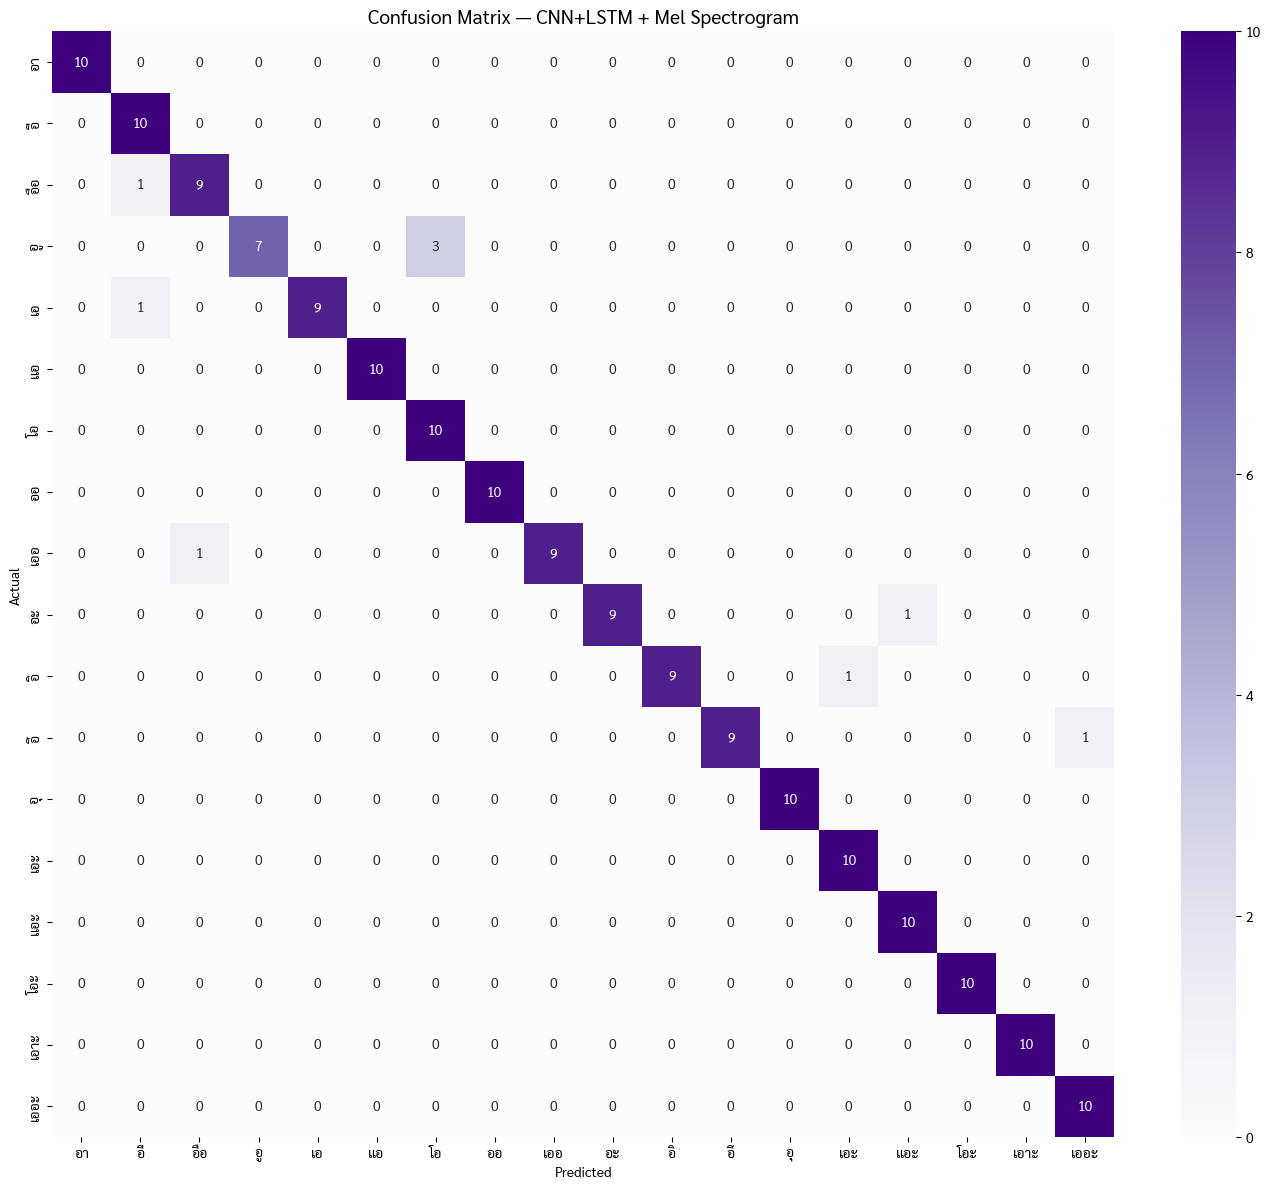

In [15]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=VOWEL_LABELS, yticklabels=VOWEL_LABELS)
plt.title('Confusion Matrix — CNN+LSTM + Mel Spectrogram', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/exp_cnnlstm_mel_cm.png', dpi=150)
plt.show()

## Section 13 — Training Curve

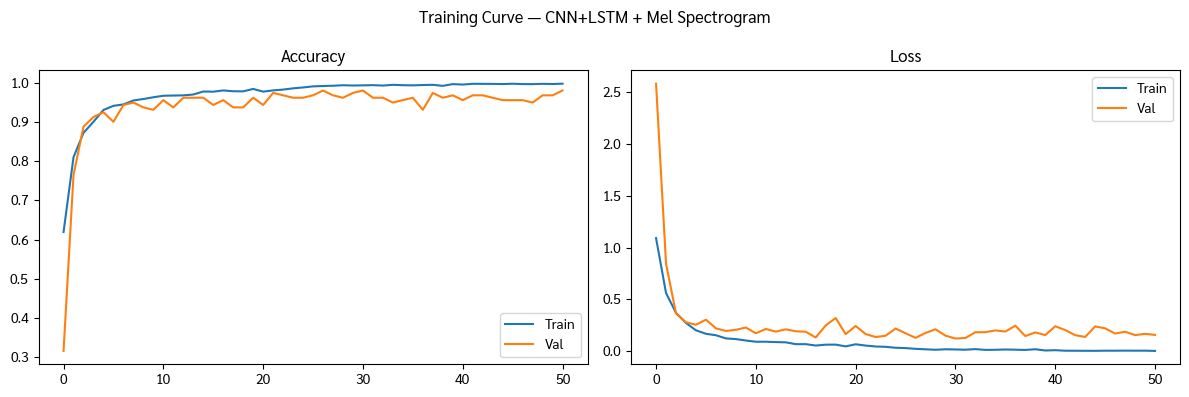

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].legend()

plt.suptitle('Training Curve — CNN+LSTM + Mel Spectrogram')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/exp_cnnlstm_mel_curve.png', dpi=150)
plt.show()

## Section 14 — Save Model & Results

In [18]:
# final_model.save('/content/drive/MyDrive/Models/cnnlstm_mel_model.h5')


print(f"CNN+LSTM+Attention+Aug | CV F1: {df_folds['val_f1_macro'].mean():.4f}±{df_folds['val_f1_macro'].std():.4f} | Test F1: {test_f1:.4f} | Test Acc: {test_acc*100:.2f}%")

CNN+LSTM+Attention+Aug | CV F1: 0.9605±0.0097 | Test F1: 0.9498 | Test Acc: 95.00%
